<a href="https://colab.research.google.com/github/dyjdlopez/mapua_ieemg_decision_science/blob/main/IE152-S/Module%201/01_02_trees_and_forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 01-02: Decision Trees & Random Forests
### IE152-S — Classification Techniques in Data Mining
**Module 1 · Companion to Lesson 1.4 (Decision Trees & Random Forests)**

In lecture, we built a decision tree by hand on a toy 8-machine dataset --- computing Gini impurity and entropy for candidate splits, watching a tree grow through recursive partitioning, and seeing how a Random Forest combines many unstable trees into one robust vote. This notebook runs that same logic on a real, messy, imbalanced industrial dataset.

**By the end of this notebook, you will have:**
1. Computed Gini impurity by hand on real sensor data, and confirmed it against what `sklearn` actually chooses
2. Fit, visualized, and evaluated a decision tree on a genuinely imbalanced classification problem
3. Demonstrated overfitting directly --- the practical motivation the lecture skipped in favor of Random Forests
4. Fit a Random Forest and shown, with real numbers, why it outperforms any single tree here
5. Applied the full workflow independently on a second, unrelated dataset

**Dataset:** AI4I 2020 Predictive Maintenance Dataset (Matzka, S. "Explainable Artificial Intelligence for Predictive Maintenance Applications," 2020 Third International Conference on Artificial Intelligence for Industries (AI4I), 2020, pp. 69-74, doi: 10.1109/AI4I49448.2020.00023). Synthetic data modeled on a real milling machine, 10,000 records.


---
## 1. Concept Primer

A quick refresher --- full explanations are in the Lesson 1.4 slides, not repeated here.

**Gini impurity** (how ``mixed'' a node is):
$$Gini = 1 - \sum_{i=1}^{k} p_i^2$$

**Entropy / Information Gain:**
$$Entropy = -\sum_{i=1}^{k} p_i \log_2 p_i \qquad\qquad IG = Entropy_{\text{parent}} - \sum_j \frac{n_j}{n} Entropy_j$$

**Recursive partitioning:** find the best split, send each subset to its own child node, repeat on each child independently until a stopping criterion is met (pure node, max depth, or min samples per leaf).

**Random Forest:** train many trees on bootstrap-sampled rows and random feature subsets, then combine their predictions by majority vote.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)


---
## 2. Dataset Introduction --- AI4I 2020 Predictive Maintenance

10,000 records from a synthetic milling machine, modeled closely on real industrial sensor data.

**Citation:** Matzka, S. (2020). Explainable Artificial Intelligence for Predictive Maintenance Applications. *2020 Third International Conference on Artificial Intelligence for Industries (AI4I)*, 69-74.

| Column | Meaning |
|---|---|
| `Type` | Product quality variant: L (low), M (medium), H (high) |
| `Air temperature [K]` | Ambient air temperature |
| `Process temperature [K]` | Process temperature |
| `Rotational speed [rpm]` | Spindle rotational speed |
| `Torque [Nm]` | Spindle torque |
| `Tool wear [min]` | Cumulative tool wear time |
| `Machine failure` | **Target.** 1 if any failure mode occurred, 0 otherwise |
| `TWF`, `HDF`, `PWF`, `OSF`, `RNF` | Individual failure-mode flags (not used here --- we predict the overall `Machine failure` label) |


In [ ]:
url = "https://raw.githubusercontent.com/dilarakesgun/predictive-maintenance-classification/main/ai4i2020.csv"
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
df.head()


Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [ ]:
df.isna().sum()


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

No missing values --- this dataset is synthetic and was generated clean. The five failure-mode flags (`TWF` through `RNF`) are sub-categories of `Machine failure`; we'll focus only on the overall binary target.

---
## 3. Exploratory Data Analysis


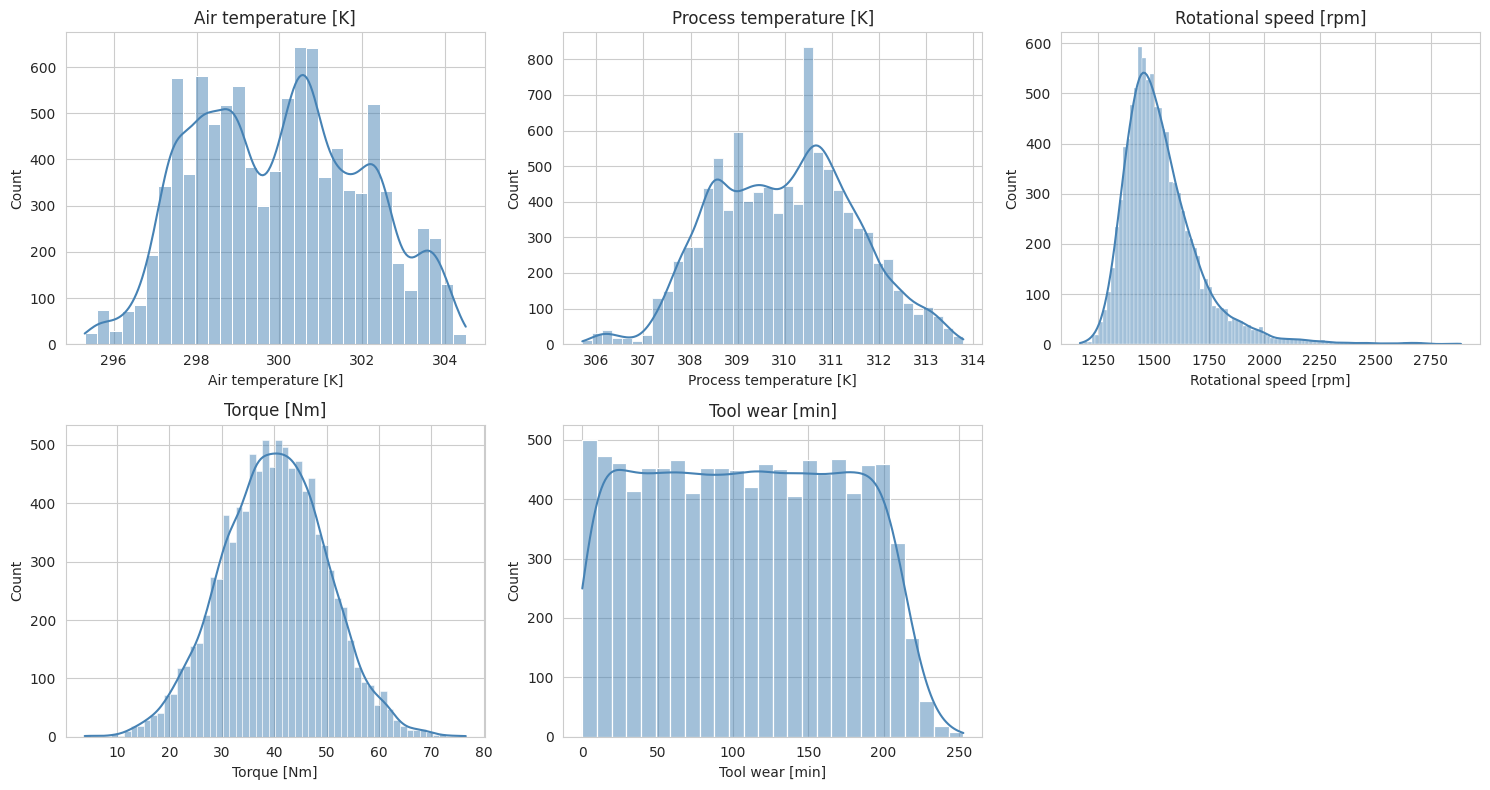

In [ ]:
feat_cols = ["Air temperature [K]", "Process temperature [K]",
             "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for i, col in enumerate(feat_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col)
axes[-1].axis("off")
plt.tight_layout()
plt.show()


### Class Balance Check on `Machine failure`

This is exactly the check Lesson 1.2 taught us to make before trusting accuracy.

Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


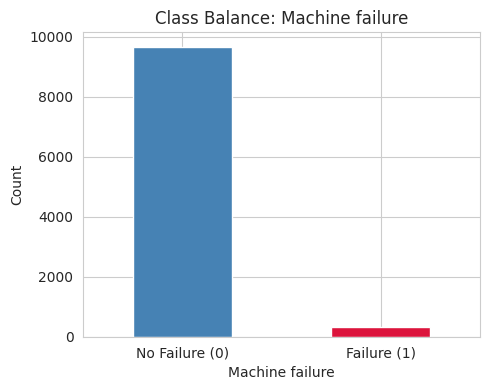

In [ ]:
fail_counts = df["Machine failure"].value_counts()
print(fail_counts)
print(f"\nFailure rate: {fail_counts[1] / fail_counts.sum():.2%}")

fail_counts.plot(kind="bar", color=["steelblue", "crimson"], figsize=(5, 4))
plt.title("Class Balance: Machine failure")
plt.xticks([0, 1], ["No Failure (0)", "Failure (1)"], rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()


**This is a severely imbalanced dataset** --- only 3.39% of machines actually failed. Remember from Lesson 1.2: a model that predicts "No Failure" for *everything* would already score about 96.6% accuracy, while catching zero real failures. Keep this firmly in mind for every metric we compute from here on --- accuracy alone will look great and mean almost nothing. We'll lean on precision, recall, and F1 instead.

---
## 4. Computing Impurity by Hand --- Confirming the Lecture's Logic on Real Data

In lecture, we hand-computed Gini impurity on a toy 8-machine dataset. Let's do the same thing here, on all 10,000 real machines, and see if it still works the same way.


In [ ]:
y = df["Machine failure"].values
n = len(y)
p1 = y.mean()
p0 = 1 - p1
gini_root = 1 - (p0**2 + p1**2)

print(f"n = {n}")
print(f"p(Fail) = {p1:.4f}, p(OK) = {p0:.4f}")
print(f"Gini_root = 1 - ({p0:.4f}^2 + {p1:.4f}^2) = {gini_root:.4f}")


n = 10000
p(Fail) = 0.0339, p(OK) = 0.9661
Gini_root = 1 - (0.9661^2 + 0.0339^2) = 0.0655


**Reading this number:** $Gini_{\text{root}} \approx 0.065$ --- much closer to 0 (pure) than to 0.5 (maximally mixed). That's just a direct consequence of the severe class imbalance: with only 3.4% failures, most of the node is already "pure" by default, long before any split happens. Gini impurity doesn't know about the *importance* of the minority class --- it only sees proportions.

### Trying Candidate Splits --- At the Median

Let's try the same thing lecture did: pick a feature, split the data at its median, and see how much the weighted Gini drops.

In [ ]:
def gini(labels):
    p1 = labels.mean()
    p0 = 1 - p1
    return 1 - (p0**2 + p1**2)

print(f"{'Feature':<28}{'Median':>10}{'Weighted Gini':>16}{'Reduction':>12}")
for feat in feat_cols:
    med = df[feat].median()
    left = df[df[feat] <= med]["Machine failure"]
    right = df[df[feat] > med]["Machine failure"]
    g_left, g_right = gini(left), gini(right)
    weighted = (len(left)/n) * g_left + (len(right)/n) * g_right
    print(f"{feat:<28}{med:>10.1f}{weighted:>16.4f}{gini_root - weighted:>12.4f}")


Feature                         Median   Weighted Gini   Reduction
Air temperature [K]              300.1          0.0652      0.0003
Process temperature [K]          310.1          0.0653      0.0002
Rotational speed [rpm]          1503.0          0.0645      0.0010
Torque [Nm]                       40.1          0.0646      0.0009
Tool wear [min]                  108.0          0.0652      0.0003


**Every median-based split barely moves the needle** --- the best reduction (Rotational speed) is only about 0.0010. That's a very different result from our clean toy example in lecture, where Temperature cut the impurity almost in half. Real data is messier --- but does that mean none of these features actually matter? Let's check what `sklearn` itself finds when it searches *every possible threshold*, not just the median.

In [ ]:
from sklearn.tree import export_text

X_root = df[feat_cols].values
stump = DecisionTreeClassifier(max_depth=1, criterion="gini", random_state=42)
stump.fit(X_root, y)

print(export_text(stump, feature_names=feat_cols))

best_feat = feat_cols[stump.tree_.feature[0]]
best_thresh = stump.tree_.threshold[0]
root_imp = stump.tree_.impurity[0]
left_imp, right_imp = stump.tree_.impurity[1], stump.tree_.impurity[2]
n_left, n_right = stump.tree_.n_node_samples[1], stump.tree_.n_node_samples[2]
weighted_opt = (n_left/n) * left_imp + (n_right/n) * right_imp

print(f"\nBest split found: {best_feat} <= {best_thresh:.1f}")
print(f"Weighted Gini after optimal split: {weighted_opt:.4f}")
print(f"Reduction: {root_imp - weighted_opt:.4f}")


|--- Torque [Nm] <= 65.00
|   |--- class: 0
|--- Torque [Nm] >  65.00
|   |--- class: 1


Best split found: Torque [Nm] <= 65.0
Weighted Gini after optimal split: 0.0572
Reduction: 0.0083


**This is the real lesson here:** `sklearn` found that splitting on **Torque at exactly 65.0 Nm** reduces Gini impurity by about **0.0083** --- roughly 8 times better than our best median-based guess (0.0010 on Rotational speed). The median is just one of thousands of thresholds a real tree considers; the algorithm doesn't guess, it **searches exhaustively** for the single best cut point on the single best feature. Our hand computation wasn't wrong --- it just wasn't trying hard enough. That exhaustive search is exactly what "recursive partitioning" does at every node, automatically, for every feature.

---
## 5. Fitting a Decision Tree

Let's fit an actual tree, deliberately kept shallow (`max_depth=4`) so we can still visualize and read it.


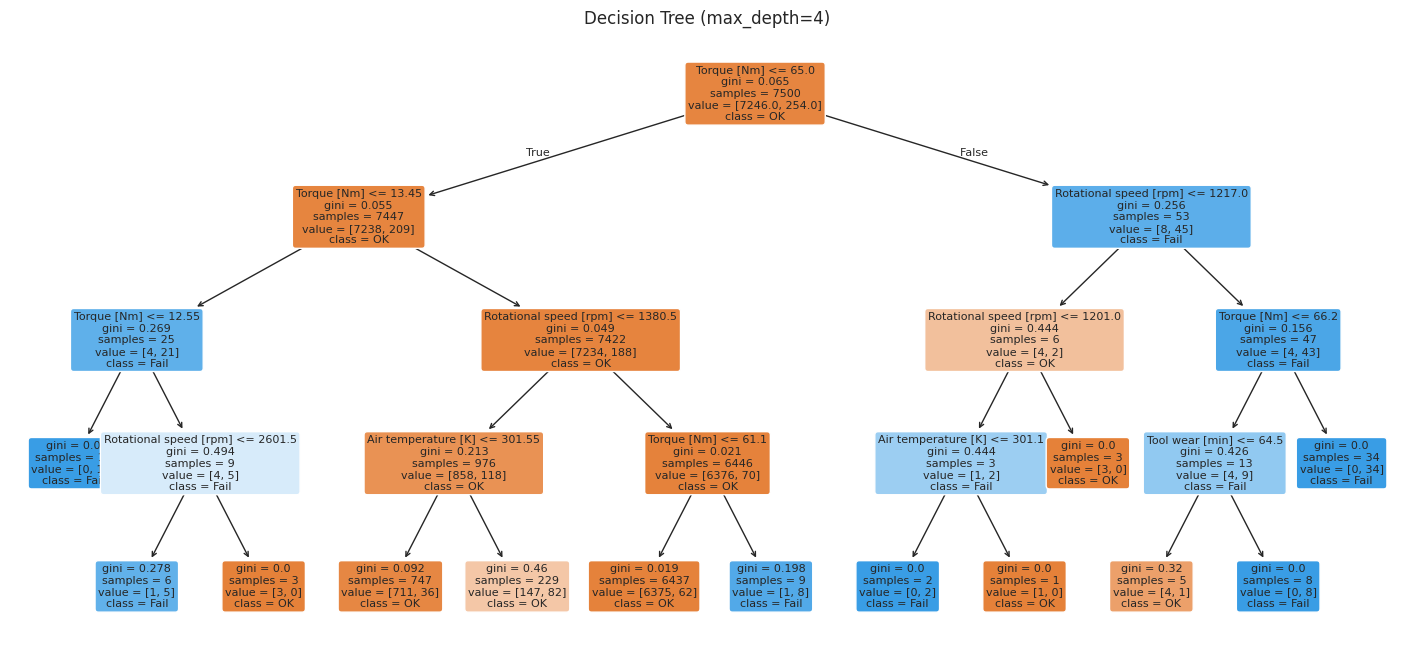

In [ ]:
X = df[feat_cols].values
y = df["Machine failure"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

tree4 = DecisionTreeClassifier(max_depth=4, random_state=42)
tree4.fit(X_train, y_train)

plt.figure(figsize=(18, 8))
plot_tree(tree4, feature_names=feat_cols, class_names=["OK", "Fail"],
          filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree (max_depth=4)")
plt.show()


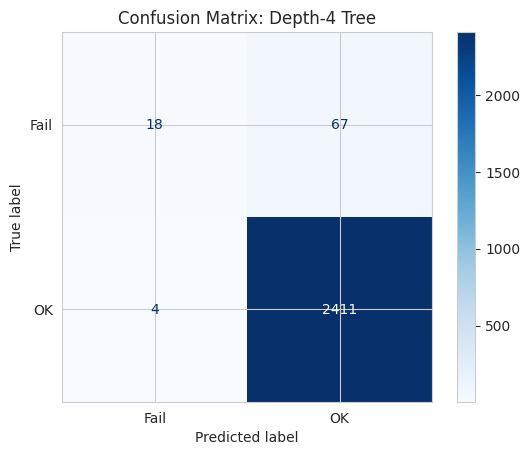

Accuracy:  0.9716
Precision: 0.8182
Recall:    0.2118
F1:        0.3364


In [ ]:
pred4 = tree4.predict(X_test)

cm4 = confusion_matrix(y_test, pred4, labels=[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=["Fail", "OK"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix: Depth-4 Tree")
plt.show()

print(f"Accuracy:  {accuracy_score(y_test, pred4):.4f}")
print(f"Precision: {precision_score(y_test, pred4):.4f}")
print(f"Recall:    {recall_score(y_test, pred4):.4f}")
print(f"F1:        {f1_score(y_test, pred4):.4f}")


**This is the imbalanced-data trap in action.** Accuracy looks great (~97%) --- but recall is only about **21%**: of every real failure in the test set, this shallow tree catches roughly 1 in 5 and misses the rest. A plant relying on this model would let most actual failures slip through undetected, while accuracy alone would never have warned us. This is precisely why Lesson 1.2 insisted on checking precision and recall, not just accuracy, for any imbalanced problem --- and precisely why, in Section 7, we'll see a deeper tree (and then a forest) do substantially better.

---
## 6. Overfitting in Practice --- Train vs.\ Test Across Depth

Lecture made the case that a single tree is unstable and prone to overfitting --- but used it mainly to motivate Random Forests, without fully showing it in action. Let's show it directly: what happens to train vs.\ test performance as we let the tree grow deeper?


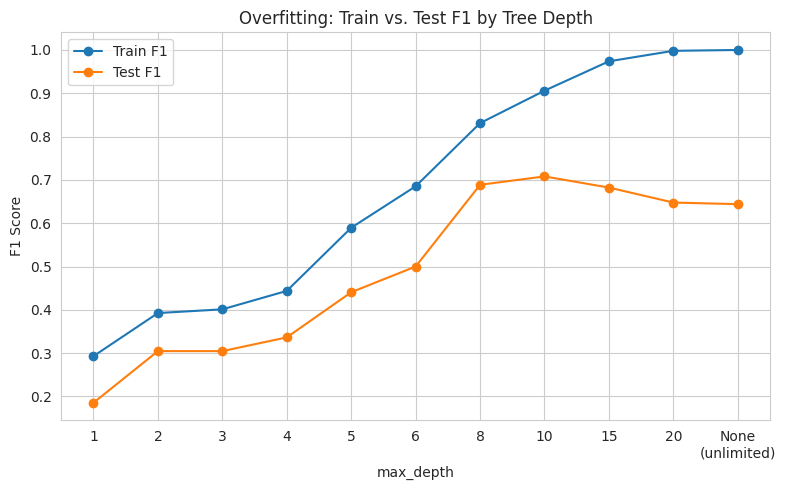

Best test F1: 0.708 at max_depth=10
Unconstrained tree: train F1=1.000, test F1=0.644


In [ ]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]
train_f1s, test_f1s = [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(X_train, y_train)
    train_f1s.append(f1_score(y_train, t.predict(X_train)))
    test_f1s.append(f1_score(y_test, t.predict(X_test)))

depth_labels = [str(d) if d is not None else "None\n(unlimited)" for d in depths]

plt.figure(figsize=(8, 5))
plt.plot(depth_labels, train_f1s, marker="o", label="Train F1")
plt.plot(depth_labels, test_f1s, marker="o", label="Test F1")
plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.title("Overfitting: Train vs. Test F1 by Tree Depth")
plt.legend()
plt.tight_layout()
plt.show()

best_idx = int(np.argmax(test_f1s))
print(f"Best test F1: {test_f1s[best_idx]:.3f} at max_depth={depths[best_idx]}")
print(f"Unconstrained tree: train F1={train_f1s[-1]:.3f}, test F1={test_f1s[-1]:.3f}")


**This is the classic overfitting curve.** Train F1 climbs steadily toward a perfect 1.000 as depth increases --- the tree is literally memorizing the training data. Test F1 tells a different story: it rises, peaks around **depth 10 (F1 $\approx$ 0.71)**, then *declines* as the tree keeps growing. Past that point, every additional split captures noise specific to the training set rather than anything that generalizes.

This single picture is why Lesson 1.4 called a single tree "unstable": the unconstrained tree (depth=21, grown with no limit) achieves a perfect training score but *worse* test performance than the depth-10 tree. More complexity isn't always better --- and this is exactly the instability a Random Forest is designed to manage.

---
## 7. Random Forests

Let's fit a Random Forest on the same data and compare it directly against our best single tree.


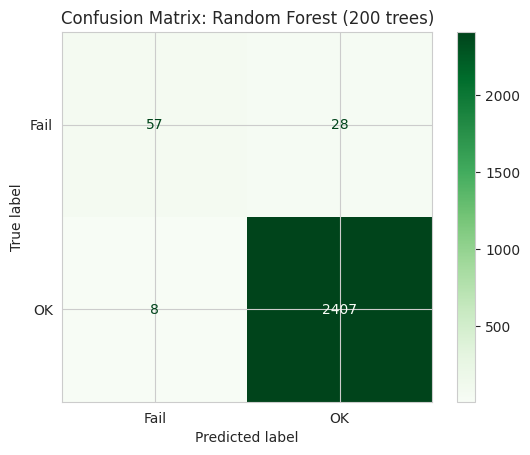

Accuracy:  0.9856
Precision: 0.8769
Recall:    0.6706
F1:        0.7600


In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

cm_rf = confusion_matrix(y_test, pred_rf, labels=[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Fail", "OK"])
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion Matrix: Random Forest (200 trees)")
plt.show()

print(f"Accuracy:  {accuracy_score(y_test, pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, pred_rf):.4f}")
print(f"F1:        {f1_score(y_test, pred_rf):.4f}")


In [ ]:
comparison = pd.DataFrame({
    "Depth-4 Tree":  [accuracy_score(y_test, pred4), precision_score(y_test, pred4),
                       recall_score(y_test, pred4), f1_score(y_test, pred4)],
    "Depth-10 Tree": [0.9812, 0.7500, 0.6706, 0.7081],
    "Random Forest": [accuracy_score(y_test, pred_rf), precision_score(y_test, pred_rf),
                       recall_score(y_test, pred_rf), f1_score(y_test, pred_rf)],
}, index=["Accuracy", "Precision", "Recall", "F1"])

comparison.round(3)


,Depth-4 Tree,Depth-10 Tree,Random Forest
Accuracy,0.972,0.981,0.986
Precision,0.818,0.750,0.877
Recall,0.212,0.671,0.671
F1,0.336,0.708,0.760


**The Random Forest wins on precision and F1, and matches the depth-10 tree's recall** --- without us having to hand-tune a depth at all. This confirms, with real numbers, exactly what Lesson 1.4 argued conceptually: combining many diverse trees produces a more robust model than carefully tuning any single one.

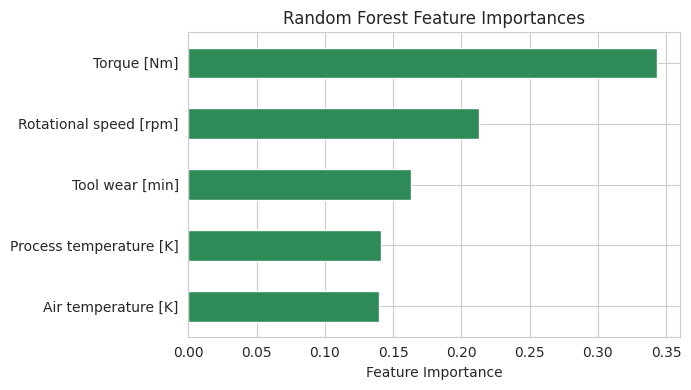

Torque [Nm]                0.343136
Rotational speed [rpm]     0.212874
Tool wear [min]            0.163306
Process temperature [K]    0.140980
Air temperature [K]        0.139703
dtype: float64

In [ ]:
importances = pd.Series(rf.feature_importances_, index=feat_cols).sort_values()

plt.figure(figsize=(7, 4))
importances.plot(kind="barh", color="seagreen")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)


**Torque is the most important feature** by a clear margin --- which lines up exactly with what we found by hand in Section 4, where Torque gave the single best Gini-reducing split at the root. The forest, built from hundreds of trees each seeing random subsets of rows and features, independently arrived at the same conclusion our one hand-computed split did.

---
## 8. Independent Activity

**Dataset:** UCI Adult / Census Income dataset --- predict whether a person's income is `<=50K` or `>50K` from census attributes.

```python
cols = ["age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
        "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
        "hours_per_week", "native_country", "income"]
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
adult = pd.read_csv(url, names=cols, na_values="?", skipinitialspace=True)
```

This dataset is **not** clean --- several columns (`workclass`, `occupation`, `native_country`) contain real missing values, and most features are categorical rather than numeric. Both of these are genuine obstacles you'll need to handle yourself.

**Your tasks:**
1. Load the dataset and check for missing values. Decide how to handle them (drop the rows, or something smarter) and justify your choice in a markdown cell.
2. Decision trees need numeric input --- encode the categorical columns (e.g., `pd.get_dummies`, or `LabelEncoder` for ordinal-feeling ones like `education`).
3. Check the class balance of `income`. Is this dataset as imbalanced as AI4I was? What does that imply for which metrics you should trust?
4. Fit a `DecisionTreeClassifier`. Visualize it at a shallow depth, and report accuracy, precision, recall, and F1 on a held-out test set.
5. Repeat the max-depth sweep from Section 6 on this dataset. Does the same overfitting pattern appear? At roughly what depth does test performance peak?
6. Fit a `RandomForestClassifier` and compare it to your best single tree, the same way Section 7 did.
7. Which features turned out most important for predicting income? Does that match your intuition?

**Stretch goal (optional):** Try `class_weight="balanced"` on either model and see whether it changes precision/recall more than adjusting `max_depth` did.


---
## Summary

| Concept | Where it appeared |
|---|---|
| Gini impurity (by hand, confirmed against `sklearn`) | Section 4 |
| Decision tree fitting, visualization, confusion matrix | Section 5 |
| Overfitting (train vs.\ test across depth) | Section 6 |
| Random Forest, feature importances | Section 7 |

**Next:** Lesson 1.5 --- Support Vector Machines, where we meet a third way to draw a decision boundary: not a single line, not a set of axis-aligned cuts, but the boundary with the *widest possible margin* between classes.
